In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # force single GPU only

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
!pip install -q tf-keras-vis transformers grad-cam torch torchvision timm
!pip install -q albumentations opencv-python-headless matplotlib seaborn
!pip install -q scikit-learn pandas numpy Pillow tqdm

Device: cuda
GPU: Tesla T4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.9 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 wh

In [4]:

import os, gc, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

✅ Using device: cuda
PyTorch version: 2.10.0+cu128


In [6]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # only show files at depth < 3
        for f in files[:3]:
            print(f'{indent}  {f}')

input/
  datasets/
    paultimothymooney/
      chest-xray-pneumonia/
        chest_xray/
          chest_xray/
            val/
              PNEUMONIA/
              NORMAL/
            test/
              PNEUMONIA/
              NORMAL/
            train/
              PNEUMONIA/
              NORMAL/
          __MACOSX/
            chest_xray/
              val/
                PNEUMONIA/
                NORMAL/
              test/
                PNEUMONIA/
                NORMAL/
              train/
                PNEUMONIA/
                NORMAL/
          val/
            PNEUMONIA/
            NORMAL/
          test/
            PNEUMONIA/
            NORMAL/
          train/
            PNEUMONIA/
            NORMAL/


In [7]:
# ── Dataset Paths (Kaggle) ─────────────────────────────────────────────────────
BASE_DIR  = Path('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray')
TRAIN_DIR = BASE_DIR / 'train'
VAL_DIR   = BASE_DIR / 'val'
TEST_DIR  = BASE_DIR / 'test'

# Count images
for split, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    for cls in ['NORMAL', 'PNEUMONIA']:
        count = len(list((d / cls).glob('*.jpeg')) + list((d / cls).glob('*.jpg')))
        print(f'{split:6s} | {cls:9s} → {count:5d} images')

Train  | NORMAL    →  1341 images
Train  | PNEUMONIA →  3875 images
Val    | NORMAL    →     8 images
Val    | PNEUMONIA →     8 images
Test   | NORMAL    →   234 images
Test   | PNEUMONIA →   390 images


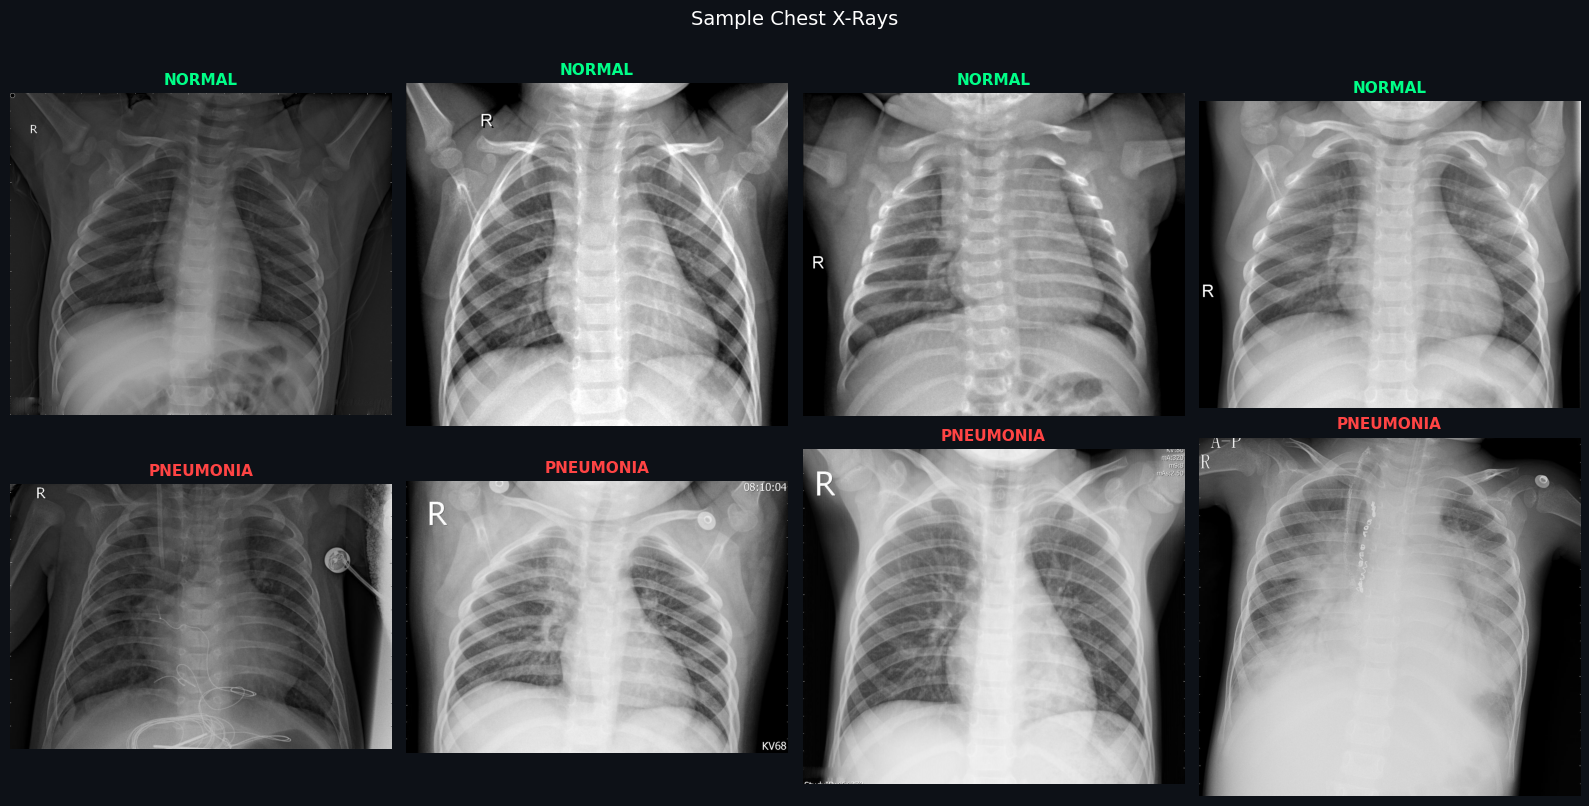

In [9]:
# ── Visualize sample images ───────────────────────────────────────────────────
def show_samples(base_dir, n=4):
    fig, axes = plt.subplots(2, n, figsize=(16, 8))
    fig.patch.set_facecolor('#0d1117')
    for ax_row, cls in zip(axes, ['NORMAL', 'PNEUMONIA']):
        imgs = list((base_dir / cls).glob('*.jpeg'))[:n]
        for ax, img_path in zip(ax_row, imgs):
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img, cmap='bone')
            ax.set_title(cls, fontsize=11, fontweight='bold',
             color='#00ff88' if cls == 'NORMAL' else '#ff4444')
            ax.axis('off')
    plt.suptitle('Sample Chest X-Rays', color='white', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR)

In [10]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_DIR  = Path('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray')
TRAIN_DIR = BASE_DIR / 'train'
VAL_DIR   = BASE_DIR / 'val'
TEST_DIR  = BASE_DIR / 'test'
IMG_SIZE  = 224

class ChestXRayDataset(Dataset):
    def __init__(self, root_dir, transform=None, return_path=False):
        self.transform   = transform
        self.return_path = return_path
        self.samples     = []
        for cls, idx in [('NORMAL',0),('PNEUMONIA',1)]:
            for ext in ['*.jpeg','*.jpg','*.png']:
                for p in (Path(root_dir)/cls).glob(ext):
                    self.samples.append((str(p), idx))
        print(f'  {Path(root_dir).name}: {len(self.samples)} images')
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        if self.return_path: return img, label, path
        return img, label

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE+20, IMG_SIZE+20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

print('✅ Dataset class and transforms ready')

✅ Dataset class and transforms ready


In [11]:
from torch.utils.data import Subset
import numpy as np

# Create indices
full_size = len(ChestXRayDataset(TRAIN_DIR))

indices = np.random.RandomState(42).permutation(full_size)

split = int(0.9 * full_size)

train_idx = indices[:split]
val_idx   = indices[split:]

# Train dataset uses train transforms
train_dataset_full = ChestXRayDataset(
    TRAIN_DIR,
    transform=train_transforms
)

# Validation dataset uses validation transforms
val_dataset_full = ChestXRayDataset(
    TRAIN_DIR,
    transform=val_transforms
)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset   = Subset(val_dataset_full, val_idx)

# Test dataset unchanged
test_dataset = ChestXRayDataset(
    TEST_DIR,
    transform=val_transforms,
    return_path=True
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

  train: 5216 images
  train: 5216 images
  train: 5216 images
  test: 624 images
Train: 4694
Val: 522
Test: 624


In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'✅ Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

✅ Train batches: 147 | Val: 17 | Test: 20


In [13]:
import timm, numpy as np, torch
import torch.nn as nn
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Subset

# ── Config ─────────────────────────────────────────────────────
NUM_CLASSES = 2
EPOCHS      = 20
LR          = 1e-4

# ── Model ──────────────────────────────────────────────────────
class PneumoniaNet(nn.Module):
    def __init__(self, num_classes=2, dr=0.3):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b3', pretrained=True,
                                          num_classes=0, global_pool='')
        fd = self.backbone.num_features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(fd), nn.Dropout(dr),
            nn.Linear(fd, 512), nn.ReLU(),
            nn.BatchNorm1d(512), nn.Dropout(dr),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Dropout(dr/2), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.head(self.pool(self.backbone.forward_features(x)))

model = PneumoniaNet().to(DEVICE)

# ── Loss / Optimizer ───────────────────────────────────────────
if isinstance(train_dataset, Subset):
    labels = [train_dataset.dataset.samples[i][1] for i in train_dataset.indices]
else:
    labels = [s[1] for s in train_dataset.samples]

counts    = np.bincount(labels)
cw        = torch.tensor(len(labels)/(NUM_CLASSES*counts), dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler    = GradScaler()

# ── Scheduler ──────────────────────────────────────────────────
scheduler = OneCycleLR(
    optimizer,
    max_lr=LR * 10,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos'
)

print(f'✅ Model, optimizer, scheduler ready | Device: {DEVICE}')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ Model, optimizer, scheduler ready | Device: cuda


In [14]:
from torch.optim.lr_scheduler import OneCycleLR

EPOCHS = 20
LR     = 1e-4

scheduler = OneCycleLR(
    optimizer,
    max_lr=LR * 10,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos'
)

print('✅ Scheduler ready')

✅ Scheduler ready


In [15]:
model = PneumoniaNet(
    num_classes=NUM_CLASSES,
    dr=0.3
).to(DEVICE)

print(f'✅ Model ready | Params: {sum(p.numel() for p in model.parameters()):,}')

✅ Model ready | Params: 11,553,194


In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

In [17]:
# ── Constants ─────────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-4
NUM_CLASSES = 2   # Binary: NORMAL vs PNEUMONIA

CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
CLASS_COLORS = {'NORMAL': '#00ff88', 'PNEUMONIA': '#ff4444'}

# ── Transforms ────────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.3),
    transforms.RandomAffine(degrees=0, shear=5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [18]:
class PneumoniaNet(nn.Module):
    """
    EfficientNetB3 backbone with:
    - Custom classification head
    - Monte Carlo Dropout for uncertainty estimation
    - Grad-CAM compatible (no global pooling hidden inside)
    """
    def __init__(self, num_classes=2, dropout_rate=0.3, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3', pretrained=pretrained, num_classes=0  # Remove head
        )
        feature_dim = self.backbone.num_features  # 1536 for B3

        # Custom classifier head with MC Dropout
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(feature_dim),
            nn.Dropout(dropout_rate),
            nn.Linear(feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(128, num_classes)
        )

        # Store last conv features for Grad-CAM
        self.feature_maps = None
        self.gradients    = None

        # Hook to capture activations & gradients
        self.backbone.conv_head.register_forward_hook(self._save_features)
        self.backbone.conv_head.register_backward_hook(self._save_gradients)

    def _save_features(self, module, input, output):
        self.feature_maps = output

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def forward(self, x):
        feat = self.backbone.forward_features(x)  # (B, C, H, W)
        out  = self.classifier(feat)
        return out

    def enable_mc_dropout(self):
        """Keep dropout active during inference for uncertainty."""
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()


model = PneumoniaNet(num_classes=NUM_CLASSES, dropout_rate=0.3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params   : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Total params   : 11,553,194
Trainable params: 11,553,194


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader, Dataset, Subset

from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import roc_auc_score

In [20]:
train_dataset = ChestXRayDataset(TRAIN_DIR, transform=train_transforms)
val_dataset   = ChestXRayDataset(TRAIN_DIR, transform=val_transforms)

  train: 5216 images
  train: 5216 images


In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [22]:
import numpy as np, warnings
import torch, torch.nn as nn, torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')
print('✅ Imports done')

✅ Imports done


In [23]:
def train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        optimizer.zero_grad()

        out = model(imgs)
        loss = criterion(out, lbls)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        loss_sum += loss.item() * imgs.size(0)
        correct += out.argmax(1).eq(lbls).sum().item()
        total += imgs.size(0)

    return loss_sum / total, correct / total

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    preds_all, labels_all, probs_all = [], [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with autocast():
            out  = model(imgs)
            loss = criterion(out, lbls)
        probs = F.softmax(out, dim=1)
        loss_sum += loss.item()*imgs.size(0)
        correct  += probs.argmax(1).eq(lbls).sum().item()
        total    += imgs.size(0)
        preds_all.extend(probs.argmax(1).cpu().numpy())
        labels_all.extend(lbls.cpu().numpy())
        probs_all.extend(probs[:,1].cpu().numpy())
    auc = roc_auc_score(labels_all, probs_all)
    return loss_sum/total, correct/total, auc, preds_all, labels_all, probs_all

print('✅ Functions defined')

✅ Functions defined


In [24]:
from torch.amp import GradScaler

scaler = GradScaler("cuda")

In [27]:
import torch, numpy as np, torch.nn as nn, torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import roc_auc_score
from torch.utils.data import Subset

EPOCHS = 20
LR     = 1e-4

# Rebuild optimizer with lower LR
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler    = GradScaler()

# Use ReduceLROnPlateau instead of OneCycleLR
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

def train_epoch(model, loader):
    model.train()
    loss_sum, correct, total = 0., 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            out  = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += imgs.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def validate(model, loader):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    preds_all, labels_all, probs_all = [], [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with autocast():
            out  = model(imgs)
            loss = criterion(out, lbls)
        probs = F.softmax(out, dim=1)
        loss_sum += loss.item() * imgs.size(0)
        correct  += probs.argmax(1).eq(lbls).sum().item()
        total    += imgs.size(0)
        preds_all.extend(probs.argmax(1).cpu().numpy())
        labels_all.extend(lbls.cpu().numpy())
        probs_all.extend(probs[:,1].cpu().numpy())
    auc = roc_auc_score(labels_all, probs_all)
    return loss_sum/total, correct/total, auc

# ── Training Loop ──────────────────────────────────────────────
history  = {'tl':[],'vl':[],'ta':[],'va':[],'auc':[]}
best_auc = 0.
SAVE_PATH = '/kaggle/working/best_model.pth'

for epoch in range(1, EPOCHS+1):
    tl, ta = train_epoch(model, train_loader)
    vl, va, auc = validate(model, val_loader)
    scheduler.step(auc)  # adjust LR based on AUC
    history['tl'].append(tl); history['vl'].append(vl)
    history['ta'].append(ta); history['va'].append(va)
    history['auc'].append(auc)
    tag = ''
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), SAVE_PATH)
        tag = '💾'
    print(f'Ep {epoch:02d}/{EPOCHS} | Train {tl:.4f}/{ta:.4f} | Val {vl:.4f}/{va:.4f} | AUC {auc:.4f} {tag}')

print(f'\n🏆 Best AUC: {best_auc:.4f}')

Ep 01/20 | Train 0.4087/0.9018 | Val 0.4031/0.9595 | AUC 0.9957 💾
Ep 02/20 | Train 0.3274/0.9609 | Val 0.3876/0.9678 | AUC 0.9974 💾
Ep 03/20 | Train 0.3070/0.9768 | Val 0.3668/0.9814 | AUC 0.9984 💾
Ep 04/20 | Train 0.3073/0.9737 | Val 0.3782/0.9741 | AUC 0.9983 
Ep 05/20 | Train 0.3024/0.9793 | Val 0.3558/0.9895 | AUC 0.9994 💾
Ep 06/20 | Train 0.2913/0.9845 | Val 0.3522/0.9931 | AUC 0.9984 
Ep 07/20 | Train 0.2982/0.9816 | Val 0.3585/0.9873 | AUC 0.9996 💾


KeyboardInterrupt: 

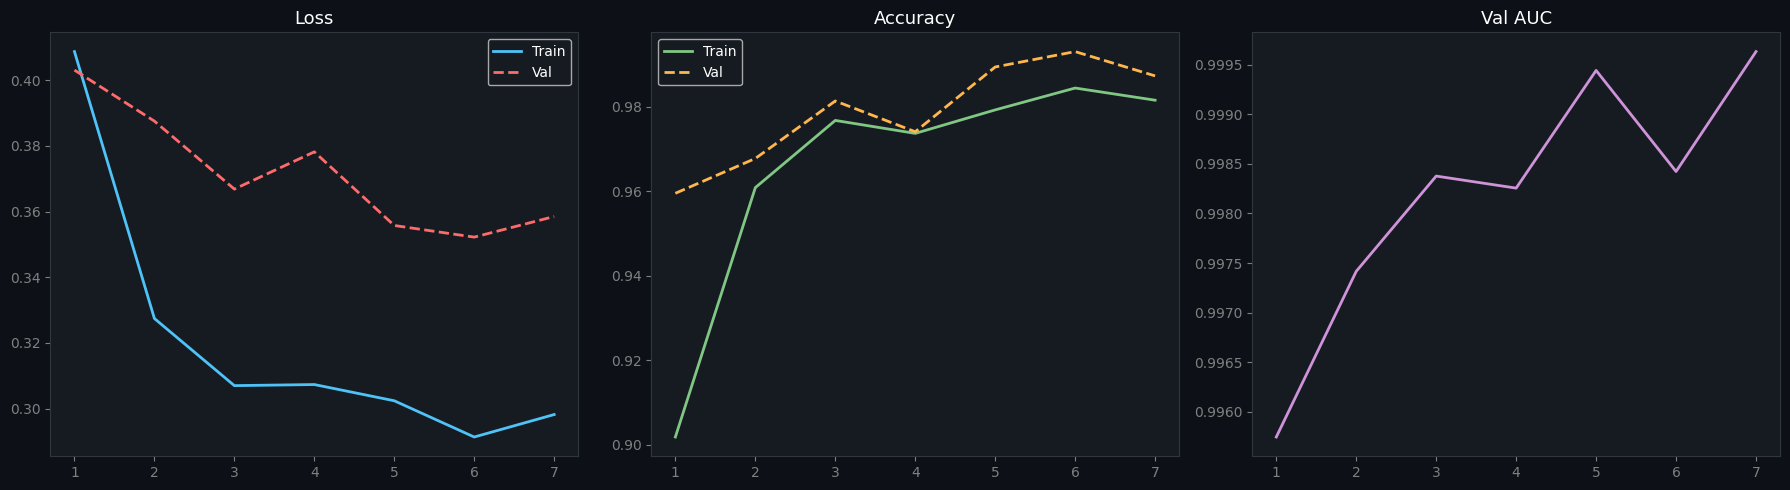

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
epochs_range = range(1, len(history['tl']) + 1)

plot_configs = [
    ('Loss',     'tl', 'vl', '#4fc3f7', '#ff6b6b'),
    ('Accuracy', 'ta', 'va', '#81c784', '#ffb74d'),
    ('Val AUC',  'auc', None, '#ce93d8', None),
]

for ax, (title, k1, k2, c1, c2) in zip(axes, plot_configs):
    ax.set_facecolor('#161b22')
    ax.plot(epochs_range, history[k1], color=c1, label='Train', lw=2)
    if k2:
        ax.plot(epochs_range, history[k2], color=c2, label='Val', lw=2, linestyle='--')
    ax.set_title(title, color='white', fontsize=13)
    ax.tick_params(colors='gray')
    for spine in ax.spines.values(): spine.set_color('#30363d')
    if k2: ax.legend(facecolor='#161b22', labelcolor='white')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

In [30]:
# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

@torch.no_grad()
def evaluate_test(model, loader):
    model.eval()
    all_preds, all_labels, all_probs, all_paths = [], [], [], []
    for images, labels, paths in tqdm(loader, desc='Evaluating'):
        images = images.to(DEVICE)
        with autocast():
            outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = probs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_paths.extend(paths)
    return np.array(all_preds), np.array(all_labels), np.array(all_probs), all_paths

test_preds, test_labels, test_probs, test_paths = evaluate_test(model, test_loader)

print('\n📊 Classification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))
print(f'Test AUC: {roc_auc_score(test_labels, test_probs):.4f}')

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


📊 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.80      0.88       234
   PNEUMONIA       0.89      0.98      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.89      0.91       624
weighted avg       0.92      0.92      0.91       624

Test AUC: 0.9341


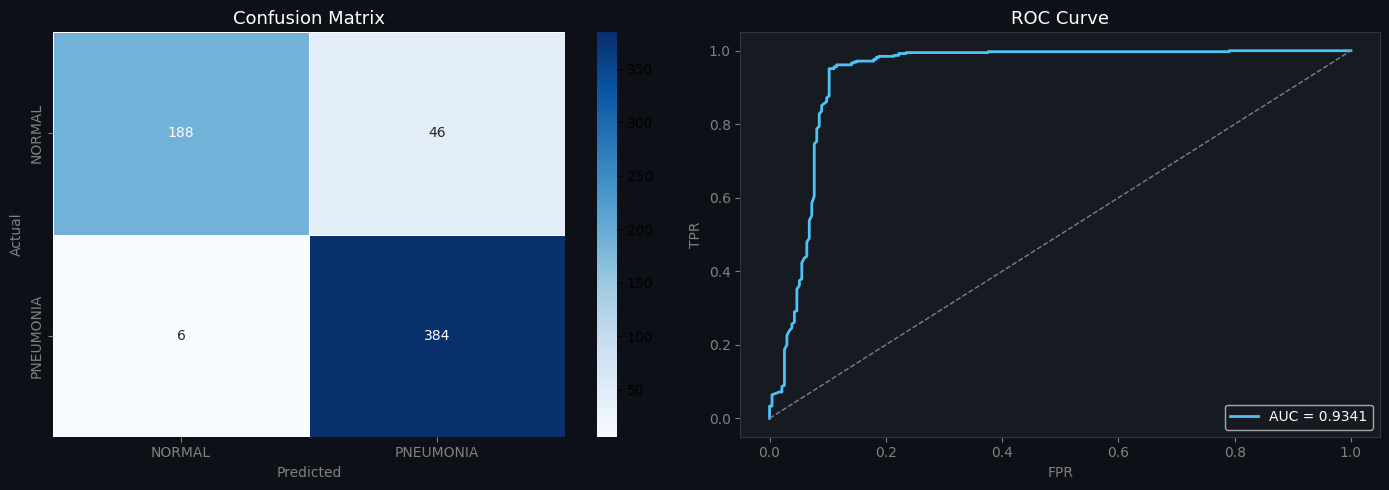

In [31]:
# ── Confusion Matrix + ROC Curve ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Confusion Matrix
ax = axes[0]
ax.set_facecolor('#161b22')
cm_matrix = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix', color='white', fontsize=13)
ax.tick_params(colors='gray')
ax.set_xlabel('Predicted', color='gray')
ax.set_ylabel('Actual', color='gray')

# ROC Curve
ax2 = axes[1]
ax2.set_facecolor('#161b22')
fpr, tpr, _ = roc_curve(test_labels, test_probs)
auc_score   = roc_auc_score(test_labels, test_probs)
ax2.plot(fpr, tpr, color='#4fc3f7', lw=2, label=f'AUC = {auc_score:.4f}')
ax2.plot([0,1], [0,1], 'gray', linestyle='--', lw=1)
ax2.set_title('ROC Curve', color='white', fontsize=13)
ax2.legend(facecolor='#161b22', labelcolor='white')
ax2.tick_params(colors='gray')
for spine in ax2.spines.values(): spine.set_color('#30363d')
ax2.set_xlabel('FPR', color='gray')
ax2.set_ylabel('TPR', color='gray')

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_metrics.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

In [33]:
import cv2
import torch.nn.functional as F
import numpy as np
from PIL import Image

class GradCAM:
    def __init__(self, model):
        self.model        = model
        self.feature_maps = None
        self.gradients    = None
        self._register_hooks()

    def _register_hooks(self):
        target_layer = self.model.backbone.conv_head

        def fwd_hook(module, inp, out):
            self.feature_maps = out.detach()

        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(fwd_hook)
        target_layer.register_backward_hook(bwd_hook)  # ← changed

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
        image_tensor.requires_grad_(True)
        output = self.model(image_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.feature_maps).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx, F.softmax(output, dim=1)[0].detach().cpu().numpy()


def overlay_gradcam(image_path, cam, alpha=0.4):
    orig    = np.array(Image.open(image_path).convert('RGB').resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap + (1 - alpha) * orig).astype(np.uint8)
    return orig, heatmap, overlay


gradcam = GradCAM(model)
print('Grad-CAM engine initialized ✅')

Grad-CAM engine initialized ✅


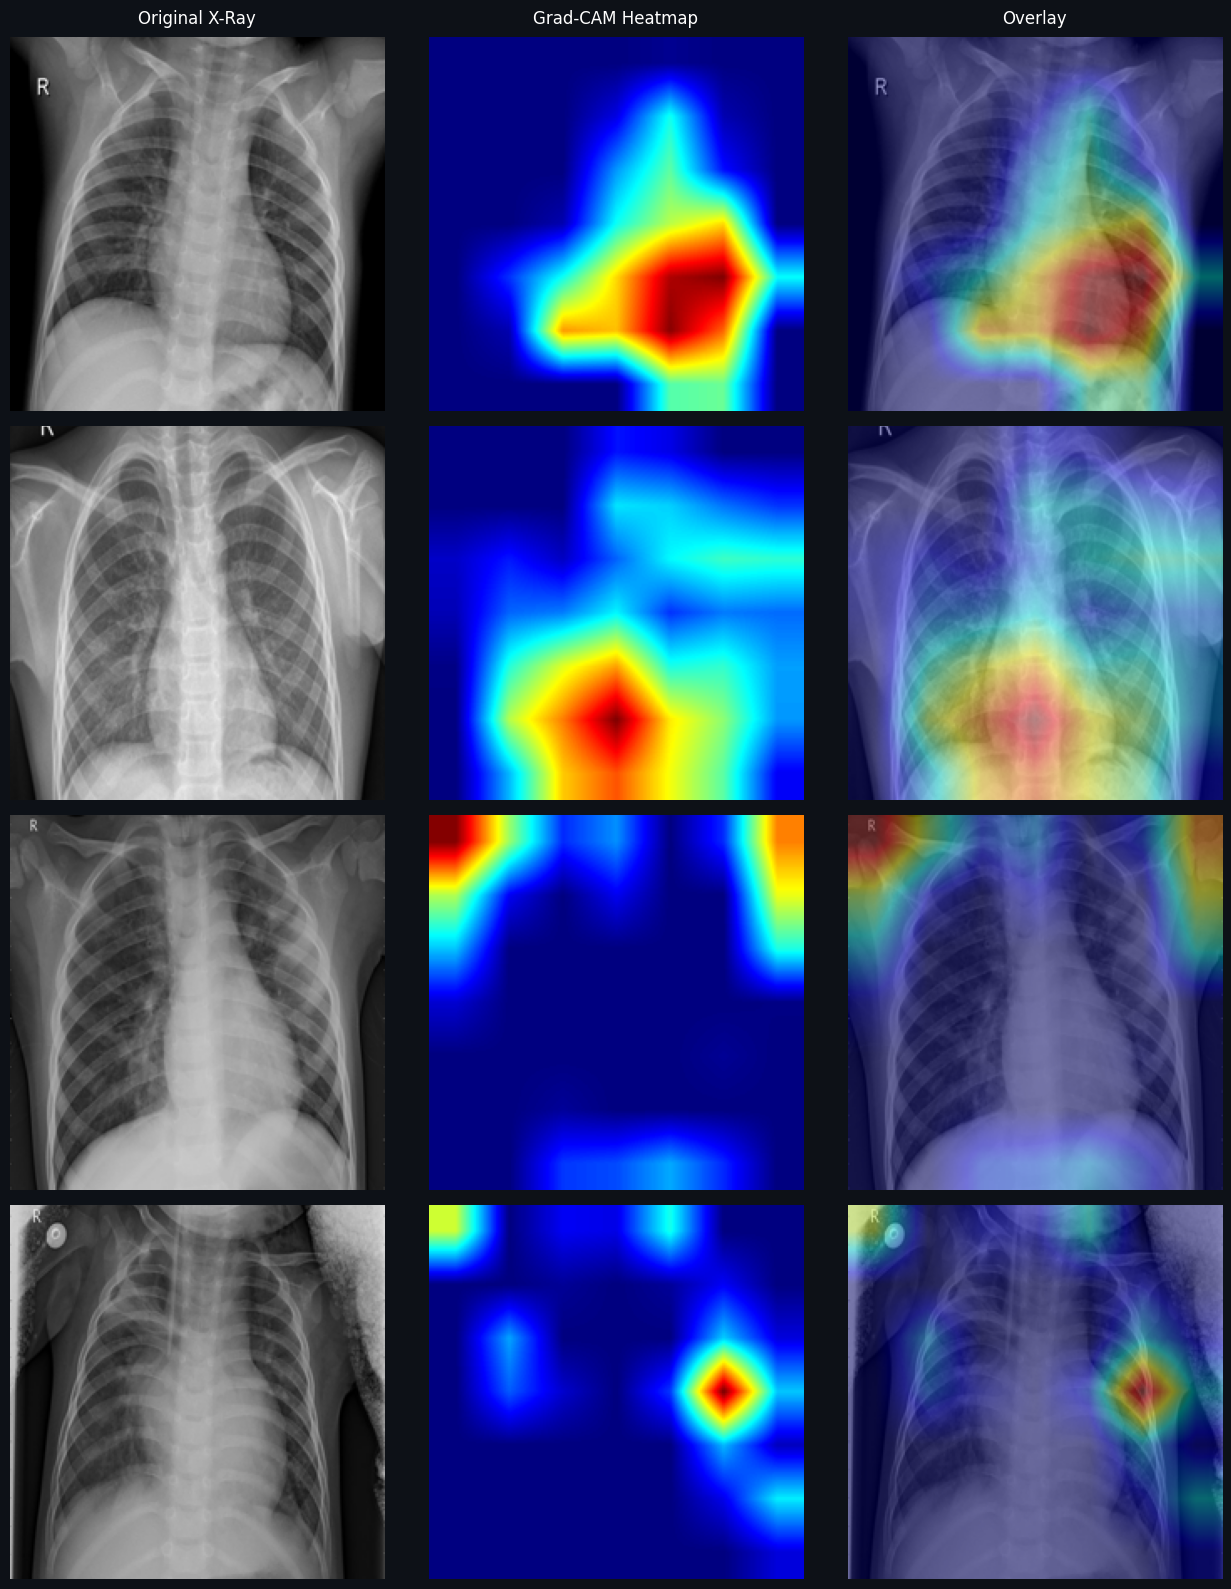

In [34]:
# ── Visualize Grad-CAM on test samples ───────────────────────────────────────
def visualize_gradcam_batch(n_samples=4):
    fig, axes = plt.subplots(n_samples, 3, figsize=(13, n_samples * 4))
    fig.patch.set_facecolor('#0d1117')
    col_titles = ['Original X-Ray', 'Grad-CAM Heatmap', 'Overlay']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, color='white', fontsize=12, pad=10)

    sample_indices = random.sample(range(len(test_dataset)), n_samples)
    for row_idx, sample_idx in enumerate(sample_indices):
        img_tensor, true_label, img_path = test_dataset[sample_idx]
        cam, pred_class, probs = gradcam.generate(img_tensor)
        orig, heatmap, overlay = overlay_gradcam(img_path, cam)
        confidence = probs[pred_class] * 100
        pred_name  = CLASS_NAMES[pred_class]
        true_name  = CLASS_NAMES[true_label]
        correct    = '✅' if pred_class == true_label else '❌'

        for col_idx, img in enumerate([orig, heatmap, overlay]):
            ax = axes[row_idx, col_idx]
            ax.set_facecolor('#161b22')
            ax.imshow(img)
            ax.axis('off')
            if col_idx == 2:
                color = '#00ff88' if pred_class == true_label else '#ff4444'
                ax.set_xlabel(f'{correct} Pred: {pred_name} ({confidence:.1f}%)\nTrue: {true_name}',
                              color=color, fontsize=10)

    plt.tight_layout()
    plt.savefig('/kaggle/working/gradcam_visualization.png', dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.show()

visualize_gradcam_batch(n_samples=4)

True label   : NORMAL
Predicted    : NORMAL (98.08%)
Uncertainty  : ±0.96%
Predictive Entropy: 0.0949


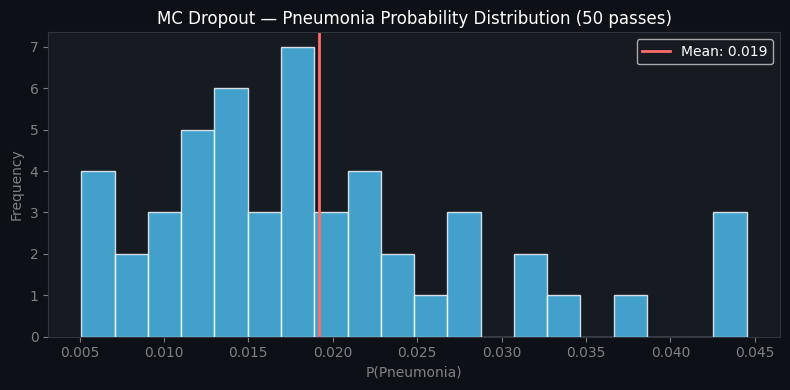

In [35]:
def mc_dropout_predict(model, image_tensor, n_passes=30):
    """
    Run N stochastic forward passes with dropout enabled.
    Returns: mean prediction, uncertainty (std), all pass probs.
    """
    model.eval()
    model.enable_mc_dropout()   # Keep dropout active

    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    probs_list = []

    with torch.no_grad():
        for _ in range(n_passes):
            output = model(image_tensor)
            probs  = F.softmax(output, dim=1).cpu().numpy()[0]
            probs_list.append(probs)

    probs_array  = np.array(probs_list)          # (n_passes, num_classes)
    mean_probs   = probs_array.mean(axis=0)      # Mean prediction
    uncertainty  = probs_array.std(axis=0)       # Epistemic uncertainty
    predictive_entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-8))  # Info entropy

    model.eval()  # Reset back
    return mean_probs, uncertainty, predictive_entropy, probs_array


# Demo on a test sample
sample_img, sample_label, sample_path = test_dataset[5]
mean_p, unc, entropy, all_passes = mc_dropout_predict(model, sample_img, n_passes=50)

print(f'True label   : {CLASS_NAMES[sample_label]}')
print(f'Predicted    : {CLASS_NAMES[mean_p.argmax()]} ({mean_p.max()*100:.2f}%)')
print(f'Uncertainty  : ±{unc[mean_p.argmax()]*100:.2f}%')
print(f'Predictive Entropy: {entropy:.4f}')

# Visualize MC distribution
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.hist(all_passes[:, 1], bins=20, color='#4fc3f7', alpha=0.8, edgecolor='white', lw=0.5)
ax.axvline(mean_p[1], color='#ff6b6b', lw=2, label=f'Mean: {mean_p[1]:.3f}')
ax.set_title('MC Dropout — Pneumonia Probability Distribution (50 passes)',
             color='white', fontsize=12)
ax.set_xlabel('P(Pneumonia)', color='gray')
ax.set_ylabel('Frequency', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#161b22', labelcolor='white')
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('/kaggle/working/mc_dropout_uncertainty.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [36]:
import textwrap
from datetime import datetime

class ClinicalExplanationEngine:
    """
    NLP-driven clinical report generator.
    Combines rule-based medical language templates with
    dynamic findings from model confidence + uncertainty.
    """

    # Radiological finding templates by confidence tier
    FINDINGS_TEMPLATES = {
        'high_pneumonia': [
            "Chest radiograph demonstrates consolidative opacification with air bronchograms "
            "consistent with lobar or segmental pneumonia. Increased interstitial markings "
            "are noted in the affected region.",

            "There is patchy airspace disease with heterogeneous opacification noted, "
            "suggestive of pneumonic consolidation. Possible pleural reaction cannot be excluded.",

            "Radiographic findings reveal bilateral perihilar infiltrates with airspace "
            "consolidation. The appearance is consistent with community-acquired pneumonia.",
        ],
        'mid_pneumonia': [
            "Subtle increased opacity is identified in the lung parenchyma. The findings "
            "are indeterminate and may represent early or evolving pneumonic process versus "
            "atelectasis. Clinical correlation strongly advised.",

            "Mild perihilar haziness is observed. While non-specific, these findings in "
            "the appropriate clinical context could represent early pneumonia.",
        ],
        'high_normal': [
            "The lungs are clear bilaterally with no focal consolidation, pleural effusion, "
            "or pneumothorax. Cardiomediastinal silhouette is within normal limits. "
            "Bony thorax is intact.",

            "No acute cardiopulmonary abnormality is identified. Lung fields appear "
            "well-aerated without evidence of infiltrate or effusion.",
        ],
        'uncertain': [
            "The radiographic findings are equivocal. High model uncertainty was detected "
            "for this image. Recommend expert radiologist review and clinical correlation.",
        ]
    }

    RECOMMENDATIONS = {
        'PNEUMONIA': {
            'high': [
                "Initiate antibiotic therapy per institutional protocol.",
                "Obtain sputum culture and sensitivity prior to antibiotic administration if feasible.",
                "Consider CT chest if clinically indicated for further characterization.",
                "Monitor O₂ saturation and consider supplemental oxygen if SpO₂ < 94%.",
                "Follow-up chest X-ray in 4–6 weeks to confirm resolution.",
            ],
            'mid': [
                "Clinical correlation with patient symptoms (fever, cough, dyspnoea) required.",
                "Consider repeat imaging in 24–48 hours if symptoms persist or worsen.",
                "Laboratory workup including CBC, CRP, and procalcitonin may be informative.",
            ]
        },
        'NORMAL': {
            'high': [
                "No acute radiographic abnormality detected. Routine follow-up as clinically indicated.",
                "If symptoms persist, consider alternative diagnoses and further workup.",
            ],
            'mid': [
                "No definitive abnormality. Clinical correlation with presenting symptoms advised.",
                "Consider repeat imaging or further investigation if clinically warranted.",
            ]
        }
    }

    UNCERTAINTY_WARNINGS = {
        'low':    "Model confidence is HIGH. Prediction reliability is strong.",
        'medium': "Model confidence is MODERATE. Recommend clinical correlation.",
        'high':   "⚠️ HIGH UNCERTAINTY detected. This prediction should NOT be used for "
                  "clinical decision-making without expert radiologist review."
    }

    def generate_report(self, prediction: str, confidence: float,
                        uncertainty: float, entropy: float,
                        patient_id: str = 'N/A') -> dict:
        """Generate a structured clinical radiology report."""

        # Determine confidence and uncertainty tiers
        conf_tier = 'high' if confidence > 0.85 else 'mid' if confidence > 0.65 else 'low'
        unc_tier  = 'low'  if uncertainty < 0.05 else 'medium' if uncertainty < 0.15 else 'high'

        # Select findings template
        if unc_tier == 'high':
            finding_key = 'uncertain'
        elif prediction == 'PNEUMONIA' and conf_tier in ('high', 'mid'):
            finding_key = f'{conf_tier}_pneumonia'
        else:
            finding_key = 'high_normal'

        templates = self.FINDINGS_TEMPLATES.get(finding_key, self.FINDINGS_TEMPLATES['uncertain'])
        findings  = random.choice(templates)

        recs = self.RECOMMENDATIONS.get(prediction, {}).get(conf_tier, [])

        report = {
            'patient_id'        : patient_id,
            'timestamp'         : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'study_type'        : 'Chest Radiograph (PA View)',
            'ai_diagnosis'      : prediction,
            'confidence_pct'    : f'{confidence * 100:.2f}%',
            'uncertainty_pct'   : f'{uncertainty * 100:.2f}%',
            'predictive_entropy': f'{entropy:.4f}',
            'confidence_tier'   : conf_tier.upper(),
            'uncertainty_level' : unc_tier.upper(),
            'radiological_findings': findings,
            'recommendations'   : recs,
            'uncertainty_note'  : self.UNCERTAINTY_WARNINGS[unc_tier],
            'disclaimer'        : 'AI-generated report. For research/educational use only. '
                                  'Not intended to replace qualified clinical judgment.'
        }
        return report

    def format_report(self, report: dict) -> str:
        """Render the report as a formatted clinical document string."""
        divider = '─' * 65
        lines   = [
            divider,
            'AUTOMATED CHEST X-RAY ANALYSIS REPORT',
            f'Powered by PneumoniaNet (EfficientNetB3 + NLP Engine)',
            divider,
            f"Patient ID   : {report['patient_id']}",
            f"Study        : {report['study_type']}",
            f"Report Date  : {report['timestamp']}",
            divider,
            'DIAGNOSTIC RESULT',
            divider,
            f"AI Diagnosis : {report['ai_diagnosis']}",
            f"Confidence   : {report['confidence_pct']} (Tier: {report['confidence_tier']})",
            f"Uncertainty  : {report['uncertainty_pct']} (Level: {report['uncertainty_level']})",
            f"Entropy      : {report['predictive_entropy']}",
            '',
            report['uncertainty_note'],
            divider,
            'RADIOLOGICAL FINDINGS',
            divider,
            textwrap.fill(report['radiological_findings'], width=65),
            divider,
            'CLINICAL RECOMMENDATIONS',
            divider,
        ]
        for i, rec in enumerate(report['recommendations'], 1):
            lines.append(f'{i}. {textwrap.fill(rec, width=63, subsequent_indent="   ")}')  
        lines += [
            divider,
            '⚠️  DISCLAIMER',
            textwrap.fill(report['disclaimer'], width=65),
            divider
        ]
        return '\n'.join(lines)


nlp_engine = ClinicalExplanationEngine()
print('NLP Clinical Explanation Engine initialized ✅')

NLP Clinical Explanation Engine initialized ✅


Testing on: NORMAL2-IM-0303-0001.jpeg (True: NORMAL)



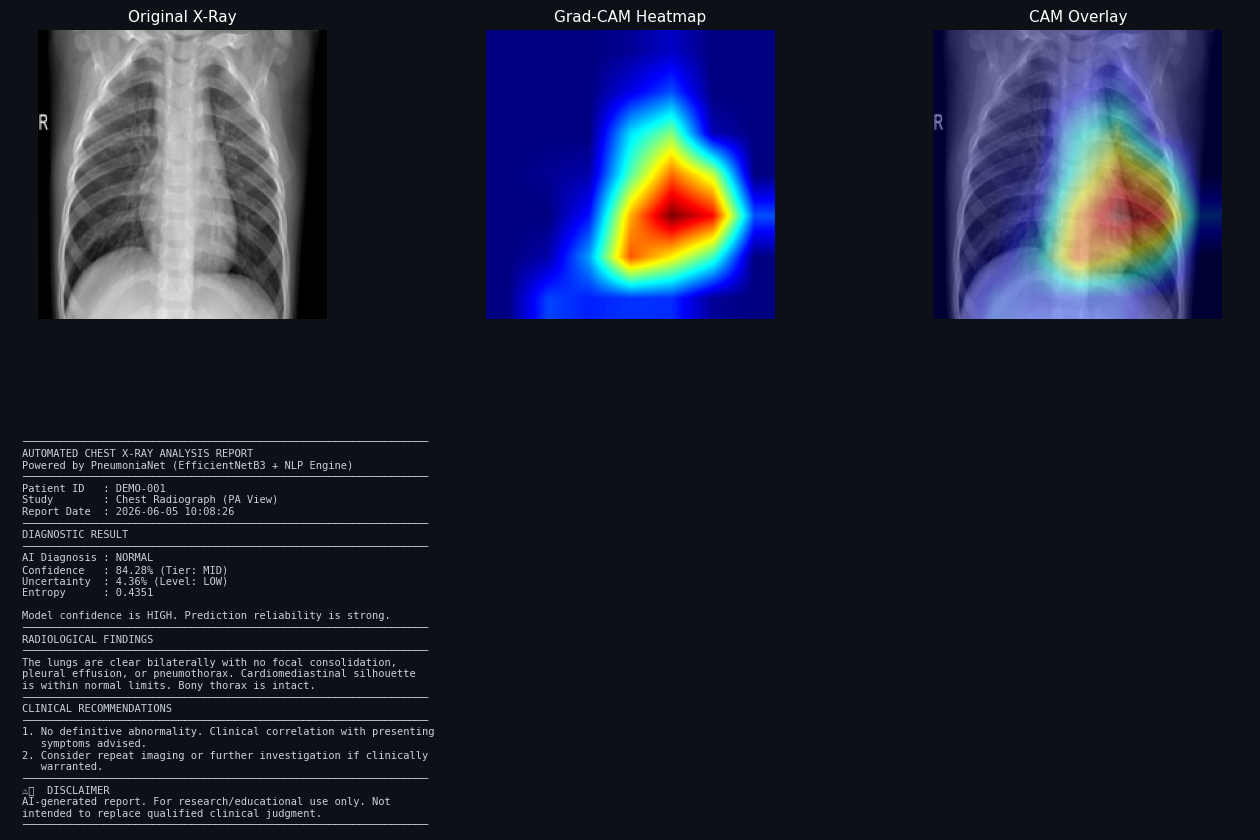

─────────────────────────────────────────────────────────────────
AUTOMATED CHEST X-RAY ANALYSIS REPORT
Powered by PneumoniaNet (EfficientNetB3 + NLP Engine)
─────────────────────────────────────────────────────────────────
Patient ID   : DEMO-001
Study        : Chest Radiograph (PA View)
Report Date  : 2026-06-05 10:08:26
─────────────────────────────────────────────────────────────────
DIAGNOSTIC RESULT
─────────────────────────────────────────────────────────────────
AI Diagnosis : NORMAL
Confidence   : 84.28% (Tier: MID)
Uncertainty  : 4.36% (Level: LOW)
Entropy      : 0.4351

Model confidence is HIGH. Prediction reliability is strong.
─────────────────────────────────────────────────────────────────
RADIOLOGICAL FINDINGS
─────────────────────────────────────────────────────────────────
The lungs are clear bilaterally with no focal consolidation,
pleural effusion, or pneumothorax. Cardiomediastinal silhouette
is within normal limits. Bony thorax is intact.
─────────────────────────

In [37]:
def full_inference_pipeline(image_path: str, patient_id: str = 'AUTO',
                             mc_passes: int = 30, show_plot: bool = True):
    """
    Complete end-to-end pipeline:
    1. Load and preprocess image
    2. MC Dropout inference (uncertainty estimation)
    3. Grad-CAM visualization
    4. NLP clinical report generation
    5. Display results
    """
    # ── 1. Preprocess ──────────────────────────────────────────────────────────
    orig_img = Image.open(image_path).convert('RGB')
    tensor   = val_transforms(orig_img)

    # ── 2. MC Dropout Inference ────────────────────────────────────────────────
    mean_probs, uncertainty, entropy, _ = mc_dropout_predict(model, tensor, n_passes=mc_passes)
    pred_idx    = mean_probs.argmax()
    pred_label  = CLASS_NAMES[pred_idx]
    confidence  = mean_probs[pred_idx]
    unc_val     = uncertainty[pred_idx]

    # ── 3. Grad-CAM ───────────────────────────────────────────────────────────
    cam, _, _ = gradcam.generate(tensor, class_idx=pred_idx)
    orig_arr, heatmap_arr, overlay_arr = overlay_gradcam(image_path, cam)

    # ── 4. NLP Report ─────────────────────────────────────────────────────────
    report = nlp_engine.generate_report(
        prediction=pred_label,
        confidence=confidence,
        uncertainty=unc_val,
        entropy=entropy,
        patient_id=patient_id
    )
    formatted_report = nlp_engine.format_report(report)

    # ── 5. Display ─────────────────────────────────────────────────────────────
    if show_plot:
        fig = plt.figure(figsize=(16, 9))
        fig.patch.set_facecolor('#0d1117')
        gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[0, 2])
        ax4 = fig.add_subplot(gs[1, :])

        for ax, arr, title in [
            (ax1, orig_arr,     'Original X-Ray'),
            (ax2, heatmap_arr,  'Grad-CAM Heatmap'),
            (ax3, overlay_arr,  'CAM Overlay'),
        ]:
            ax.set_facecolor('#161b22')
            ax.imshow(arr)
            ax.set_title(title, color='white', fontsize=11)
            ax.axis('off')

        # Prediction bar
        bar_color = '#ff4444' if pred_label == 'PNEUMONIA' else '#00ff88'
        ax3.set_xlabel(f'  {pred_label}  ({confidence*100:.1f}%)  ±{unc_val*100:.1f}%',
                       color=bar_color, fontsize=11, fontweight='bold')

        # Report text panel
        ax4.set_facecolor('#0d1117')
        ax4.axis('off')
        ax4.text(0.01, 0.99, formatted_report, transform=ax4.transAxes,
                 fontsize=7.5, color='#c9d1d9', va='top',
                 fontfamily='monospace', wrap=True)

        plt.savefig('/kaggle/working/inference_output.png', dpi=150,
                    bbox_inches='tight', facecolor='#0d1117')
        plt.show()

    print(formatted_report)
    return report


# ── Run on a random test image ─────────────────────────────────────────────────
sample = random.choice(test_dataset.samples)
print(f'Testing on: {Path(sample[0]).name} (True: {CLASS_NAMES[sample[1]]})\n')
result = full_inference_pipeline(sample[0], patient_id='DEMO-001')

In [38]:
# ── Save predictions CSV ───────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'image_path' : [Path(p).name for p in test_paths],
    'true_label' : [CLASS_NAMES[l] for l in test_labels],
    'predicted'  : [CLASS_NAMES[p] for p in test_preds],
    'prob_normal'    : 1 - test_probs,
    'prob_pneumonia' : test_probs,
    'correct'    : (test_preds == test_labels)
})
results_df.to_csv('/kaggle/working/test_predictions.csv', index=False)
print(results_df.head(10))
print(f'\nTotal: {len(results_df)} | Correct: {results_df.correct.sum()} | '
      f'Accuracy: {results_df.correct.mean():.4f}')

                  image_path true_label  predicted  prob_normal  \
0  NORMAL2-IM-0336-0001.jpeg     NORMAL  PNEUMONIA     0.169922   
1          IM-0101-0001.jpeg     NORMAL  PNEUMONIA     0.136719   
2  NORMAL2-IM-0337-0001.jpeg     NORMAL     NORMAL     0.975586   
3  NORMAL2-IM-0198-0001.jpeg     NORMAL  PNEUMONIA     0.122070   
4          IM-0013-0001.jpeg     NORMAL     NORMAL     0.983887   
5          IM-0103-0001.jpeg     NORMAL     NORMAL     0.982422   
6  NORMAL2-IM-0139-0001.jpeg     NORMAL     NORMAL     0.972168   
7  NORMAL2-IM-0313-0001.jpeg     NORMAL     NORMAL     0.980957   
8  NORMAL2-IM-0340-0001.jpeg     NORMAL  PNEUMONIA     0.375000   
9  NORMAL2-IM-0378-0001.jpeg     NORMAL     NORMAL     0.958984   

   prob_pneumonia  correct  
0        0.830078    False  
1        0.863281    False  
2        0.024445     True  
3        0.877930    False  
4        0.016098     True  
5        0.017731     True  
6        0.028061     True  
7        0.018982     True  
8

In [39]:
# ── Final summary ──────────────────────────────────────────────────────────────
print('=' * 65)
print('  PROJECT SUMMARY: Pneumonia Detection + NLP Explanation')
print('=' * 65)
print(f'  Model       : EfficientNetB3 (fine-tuned)')
print(f'  Test AUC    : {roc_auc_score(test_labels, test_probs):.4f}')
print(f'  Test Acc    : {(test_preds == test_labels).mean():.4f}')
print(f'  XAI Method  : Grad-CAM')
print(f'  Uncertainty : Monte Carlo Dropout (N=30 passes)')
print(f'  NLP Engine  : Template-based Clinical Report Generation')
print('=' * 65)
print('\n📁 Output Files:')
for f in Path('/kaggle/working').glob('*'):
    print(f'  {f.name}')

  PROJECT SUMMARY: Pneumonia Detection + NLP Explanation
  Model       : EfficientNetB3 (fine-tuned)
  Test AUC    : 0.9341
  Test Acc    : 0.9167
  XAI Method  : Grad-CAM
  Uncertainty : Monte Carlo Dropout (N=30 passes)
  NLP Engine  : Template-based Clinical Report Generation

📁 Output Files:
  test_predictions.csv
  mc_dropout_uncertainty.png
  evaluation_metrics.png
  best_model.pth
  inference_output.png
  .virtual_documents
  gradcam_visualization.png
  training_curves.png
